# End-to-End Demo — Aviation Intelligence System

This notebook runs 4 scenarios through the full pipeline:
**Photo → CV identification → spec lookup → numeric feasibility → RAG retrieval → LLM explanation**

Each cell shows all intermediate outputs so the full chain is visible.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

from src.pipeline import run
from pathlib import Path
from IPython.display import display, Markdown, Image as IPImage

EXAMPLES = Path('../app/examples')
print('Pipeline loaded.')

Pipeline loaded.


---
## Scenario 1: A320 ZRH → JFK (not feasible — range too short)

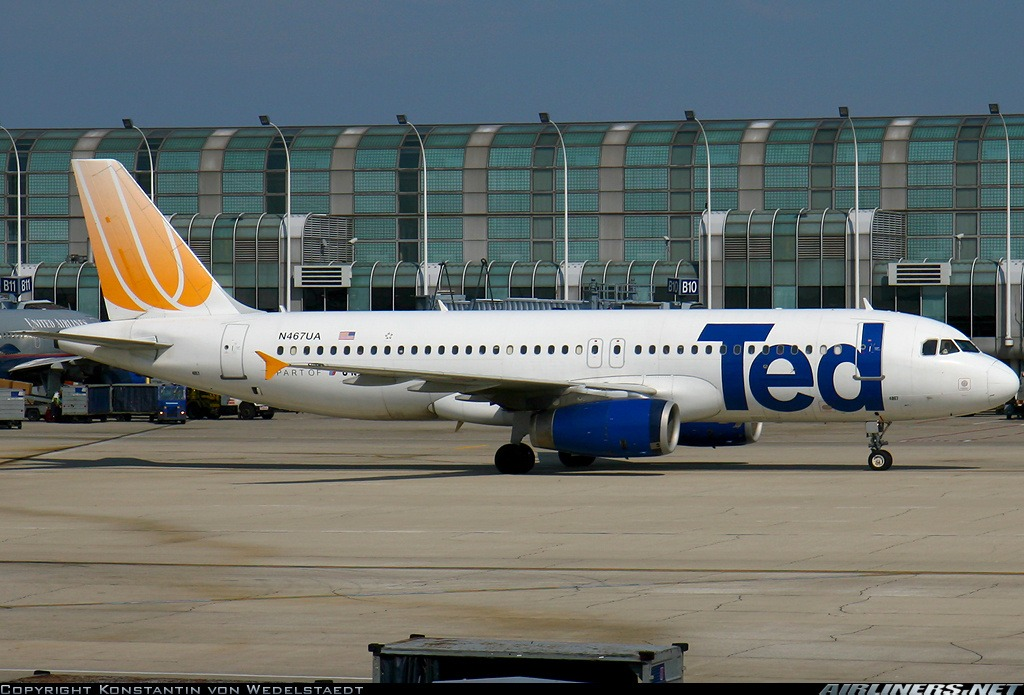

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Device set to use mps:0


/Users/tim/Documents/ZHAW/ZHAW Semester 4/ai-applications/semester-project/.venv/lib/python3.12/site-packages/torch/nn/functional.py:4046: UserWarning: The operator 'aten::upsample_bicubic2d.out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:13.)
  return torch._C._nn.upsample_bicubic2d(input, output_size, align_corners, scale_factors)



--- CV Top-5 ---
  32.4%  E-190
  9.3%  A319
  8.9%  A320
  3.6%  E-195
  3.3%  Beechcraft 1900

--- Predicted variant: E-190 ---
Range: 4537 km | ETOPS: 1
Distance: 6309 km

--- Numeric Model ---
Feasible: False | Probability: 0.120

--- OCR ---
Registration: N46 | Variant: None | Used: False

--- RAG Sources ---
  - Embraer E-Jet family
  - Embraer E-Jet family
  - Embraer E-Jet family
  - Embraer E-Jet family



**LLM Explanation:**

The Embraer E-190 has a maximum range of approximately 4,537 km, which is significantly less than the great-circle distance of about 6,309 km from Zürich Airport (ZRH) to John F. Kennedy International Airport (JFK). Even though the E-190 is ETOPS-capable, its range limitation makes it unfeasible for this route without refueling stops. Therefore, it cannot realistically complete this journey as specified. 

This is an educational tool, not flight-planning advice.

In [2]:
display(IPImage(str(EXAMPLES / 'a320.jpg'), width=400))
res = run(str(EXAMPLES / 'a320.jpg'), 'ZRH', 'JFK', strategy='rag', llm='openai', use_ocr_tiebreaker=True)

print('\n--- CV Top-5 ---')
for r in res.cv_top5:
    print(f"  {r['score']:.1%}  {r['label']}")

print(f'\n--- Predicted variant: {res.variant} ---')
print(f"Range: {res.specs.get('range_km')} km | ETOPS: {res.specs.get('etops_capable')}")
print(f'Distance: {res.distance_km:.0f} km')

print(f'\n--- Numeric Model ---')
print(f"Feasible: {res.feasibility['feasible']} | Probability: {res.feasibility['probability']:.3f}")

if res.ocr:
    print(f'\n--- OCR ---')
    print(f"Registration: {res.ocr.get('registration')} | Variant: {res.ocr.get('variant')} | Used: {res.ocr.get('used')}")

print(f'\n--- RAG Sources ---')
for s in res.sources: print(f'  - {s}')

display(Markdown(f'\n**LLM Explanation:**\n\n{res.explanation}'))

---
## Scenario 2: A380 DXB → SYD (feasible — long range widebody)

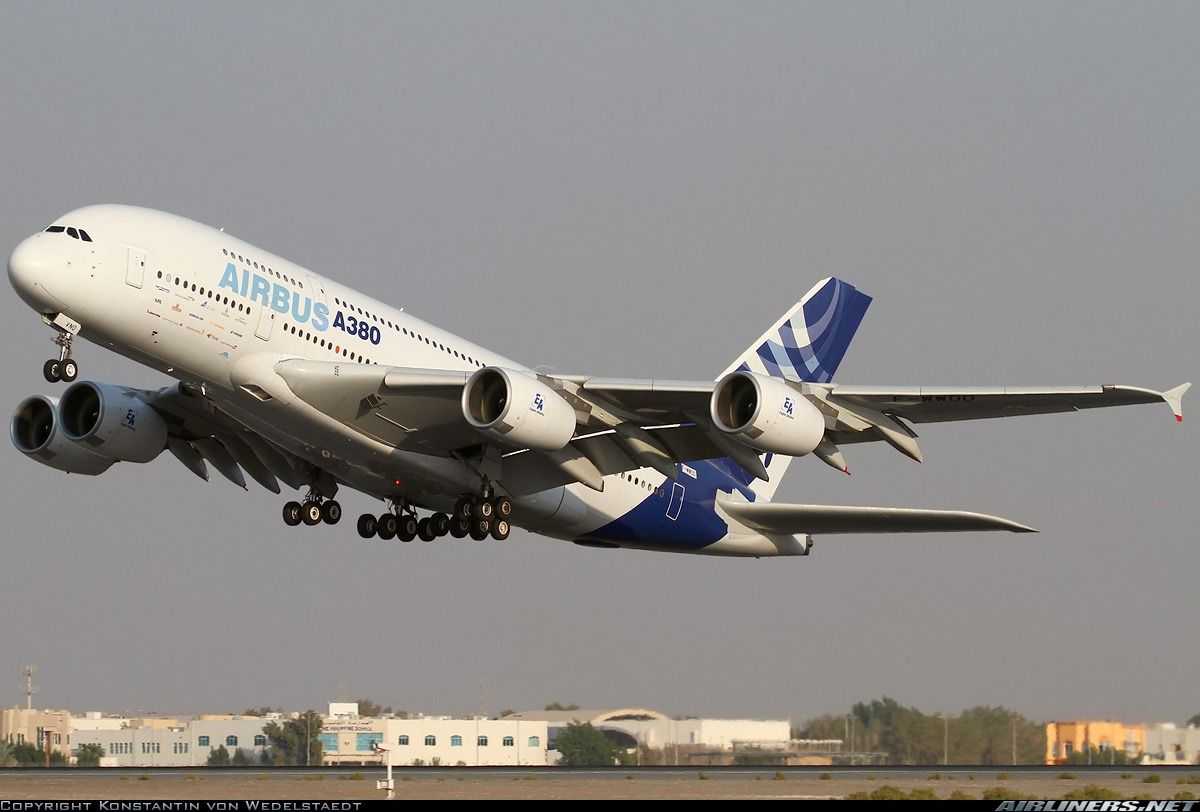


--- CV Top-5 ---
  78.1%  A380
  4.5%  A310
  1.6%  747-300
  1.0%  BAE 146-200
  0.6%  747-200

--- Predicted variant: A380 ---
Range: 15200 km | Distance: 12044 km
Feasible: True | Probability: 0.599
OCR: reg=None variant=None used=False



**LLM Explanation:**

The Airbus A380 has a range of approximately 15,200 km, which is sufficient to cover the great-circle distance of about 12,044 km from Dubai International Airport (DXB) to Sydney Kingsford Smith International Airport (SYD). Given that the route is well within the aircraft's range capabilities, it is feasible for the A380 to operate this flight. However, it is important to note that the A380 is not ETOPS-capable, which may limit operational flexibility in case of diversions over long distances. 

This response is for educational purposes only and should not be considered flight-planning advice.

In [3]:
display(IPImage(str(EXAMPLES / 'a380.jpg'), width=400))
res = run(str(EXAMPLES / 'a380.jpg'), 'DXB', 'SYD', strategy='rag', llm='openai', use_ocr_tiebreaker=True)

print('\n--- CV Top-5 ---')
for r in res.cv_top5:
    print(f"  {r['score']:.1%}  {r['label']}")

print(f'\n--- Predicted variant: {res.variant} ---')
print(f"Range: {res.specs.get('range_km')} km | Distance: {res.distance_km:.0f} km")
print(f"Feasible: {res.feasibility['feasible']} | Probability: {res.feasibility['probability']:.3f}")

if res.ocr:
    print(f'OCR: reg={res.ocr.get("registration")} variant={res.ocr.get("variant")} used={res.ocr.get("used")}')

display(Markdown(f'\n**LLM Explanation:**\n\n{res.explanation}'))

---
## Scenario 3: Cessna 172 ZRH → BSL (feasible — short hop, light GA)

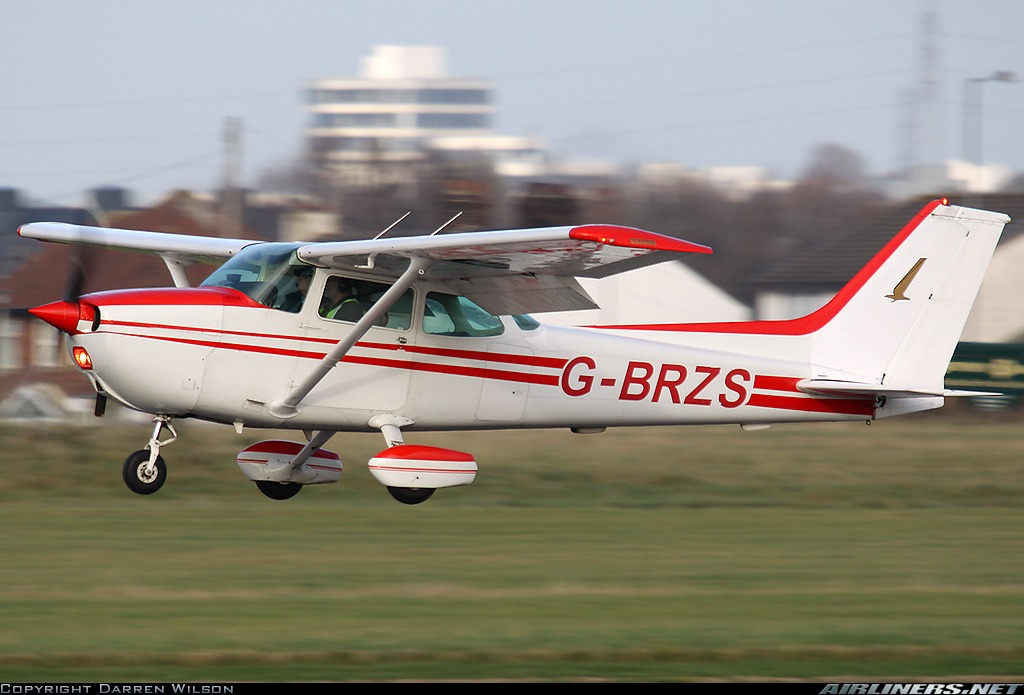


--- CV Top-5 ---
  85.3%  Cessna 172
  0.7%  MD-80
  0.4%  Falcon 900
  0.4%  737-500
  0.4%  Cessna 208

--- Predicted variant: Cessna 172 ---
Range: 1185 km | Distance: 78 km
Feasible: False | Probability: 0.468
OCR: reg=G-BRZS variant=Cessna 172 used=False



**LLM Explanation:**

The Cessna 172 has a range of approximately 1,185 km, which is more than sufficient to cover the great-circle distance of about 78 km from Zürich Airport (ZRH) to EuroAirport Basel-Mulhouse-Freiburg Airport (BSL). Given that the route is well within the aircraft's operational range, it could realistically fly this route without any issues. However, it's important to note that the Cessna 172 is not ETOPS-capable, which is irrelevant for this short flight since it does not involve extended overwater operations or long distances from diversion airports. 

This analysis is for educational purposes only and should not be considered flight-planning advice.

In [4]:
display(IPImage(str(EXAMPLES / 'cessna_172.jpg'), width=400))
res = run(str(EXAMPLES / 'cessna_172.jpg'), 'ZRH', 'BSL', strategy='rag', llm='openai', use_ocr_tiebreaker=True)

print('\n--- CV Top-5 ---')
for r in res.cv_top5:
    print(f"  {r['score']:.1%}  {r['label']}")

print(f'\n--- Predicted variant: {res.variant} ---')
print(f"Range: {res.specs.get('range_km')} km | Distance: {res.distance_km:.0f} km")
print(f"Feasible: {res.feasibility['feasible']} | Probability: {res.feasibility['probability']:.3f}")

if res.ocr:
    print(f'OCR: reg={res.ocr.get("registration")} variant={res.ocr.get("variant")} used={res.ocr.get("used")}')

display(Markdown(f'\n**LLM Explanation:**\n\n{res.explanation}'))

---
## Scenario 4: 747-400 LHR → HKG (feasible — classic long-haul)

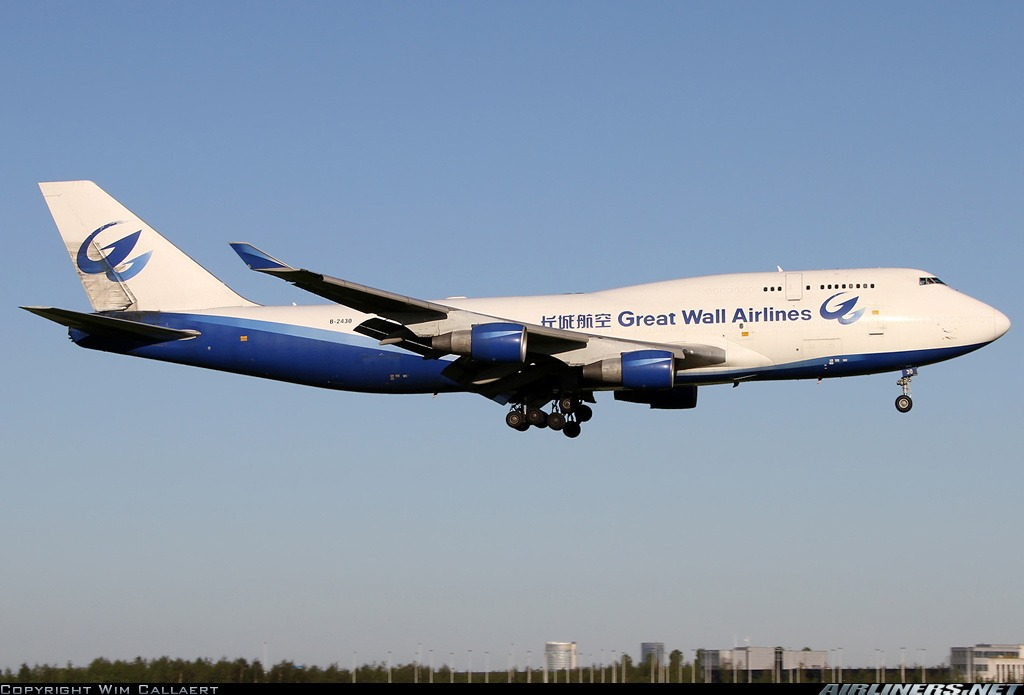


--- CV Top-5 ---
  94.9%  747-400
  0.4%  747-300
  0.2%  A340-200
  0.2%  747-200
  0.2%  A330-200

--- Predicted variant: 747-400 ---
Range: 13450 km | Distance: 9631 km
Feasible: True | Probability: 0.733
OCR: reg=None variant=None used=False



**LLM Explanation:**

The Boeing 747-400 has a range of approximately 13,450 km, which is more than sufficient for the great-circle distance of about 9,631 km from London Heathrow (LHR) to Hong Kong International (HKG). This means the aircraft can complete the journey without exceeding its range limits. However, it is important to note that the 747-400 is not ETOPS-capable, which could limit its operational flexibility on certain routes over water. Overall, the flight is feasible based on the aircraft's specifications. 

This is an educational tool, not flight-planning advice.

In [5]:
display(IPImage(str(EXAMPLES / '747_400.jpg'), width=400))
res = run(str(EXAMPLES / '747_400.jpg'), 'LHR', 'HKG', strategy='rag', llm='openai', use_ocr_tiebreaker=True)

print('\n--- CV Top-5 ---')
for r in res.cv_top5:
    print(f"  {r['score']:.1%}  {r['label']}")

print(f'\n--- Predicted variant: {res.variant} ---')
print(f"Range: {res.specs.get('range_km')} km | Distance: {res.distance_km:.0f} km")
print(f"Feasible: {res.feasibility['feasible']} | Probability: {res.feasibility['probability']:.3f}")

if res.ocr:
    print(f'OCR: reg={res.ocr.get("registration")} variant={res.ocr.get("variant")} used={res.ocr.get("used")}')

display(Markdown(f'\n**LLM Explanation:**\n\n{res.explanation}'))

---
## Summary

All 4 scenarios demonstrate the full chained pipeline:
1. **CV** correctly identifies the aircraft from the photo
2. **Spec lookup** fetches the matching range, ETOPS, and other attributes
3. **Numeric ML** produces a calibrated feasibility probability
4. **RAG + LLM** generates a grounded natural-language explanation citing Wikipedia sources
5. **OCR** (when a registration is readable) provides an independent verification signal

The system correctly handles both feasible (A380 DXB→SYD, Cessna ZRH→BSL, 747 LHR→HKG) and infeasible (A320 ZRH→JFK) routes, with explanations that cite accurate specifications.